**Data Augmentation**

# # **Imports and Setup**

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Define dataset path
dataset_path = "/kaggle/input/dataset/fane_data"

# Prepare data lists
images = []
labels = []

# Load images without resizing
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB

            if img is not None:
                images.append(img)
                labels.append(class_name)

# Convert to NumPy arrays
images = np.array(images, dtype=object)  # Keep object dtype for variable sizes
labels = np.array(labels)




Classes Found: ['surprise', 'fear', 'confused', 'angry', 'neutral', 'sad', 'shy', 'disgust', 'happy']


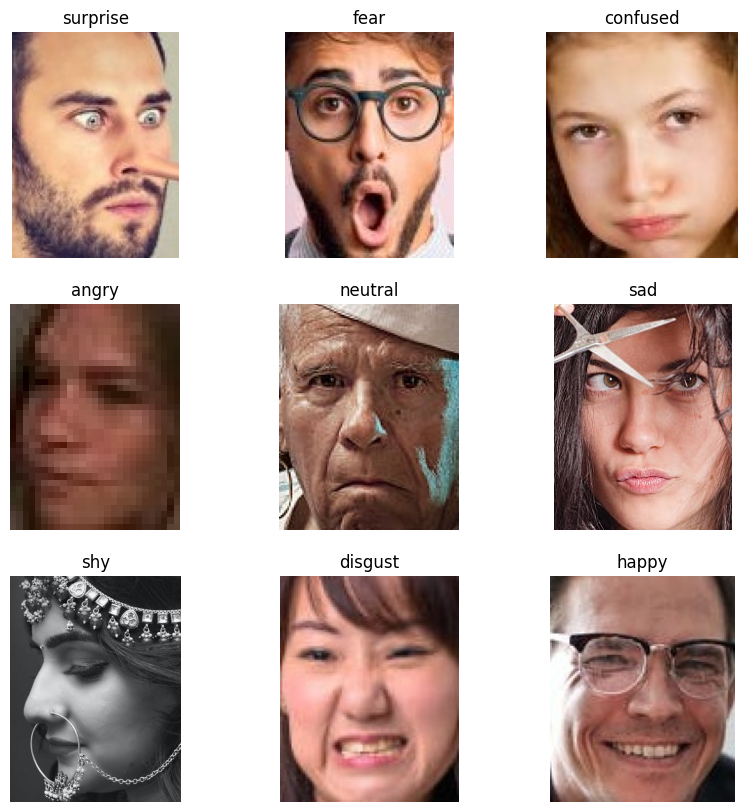

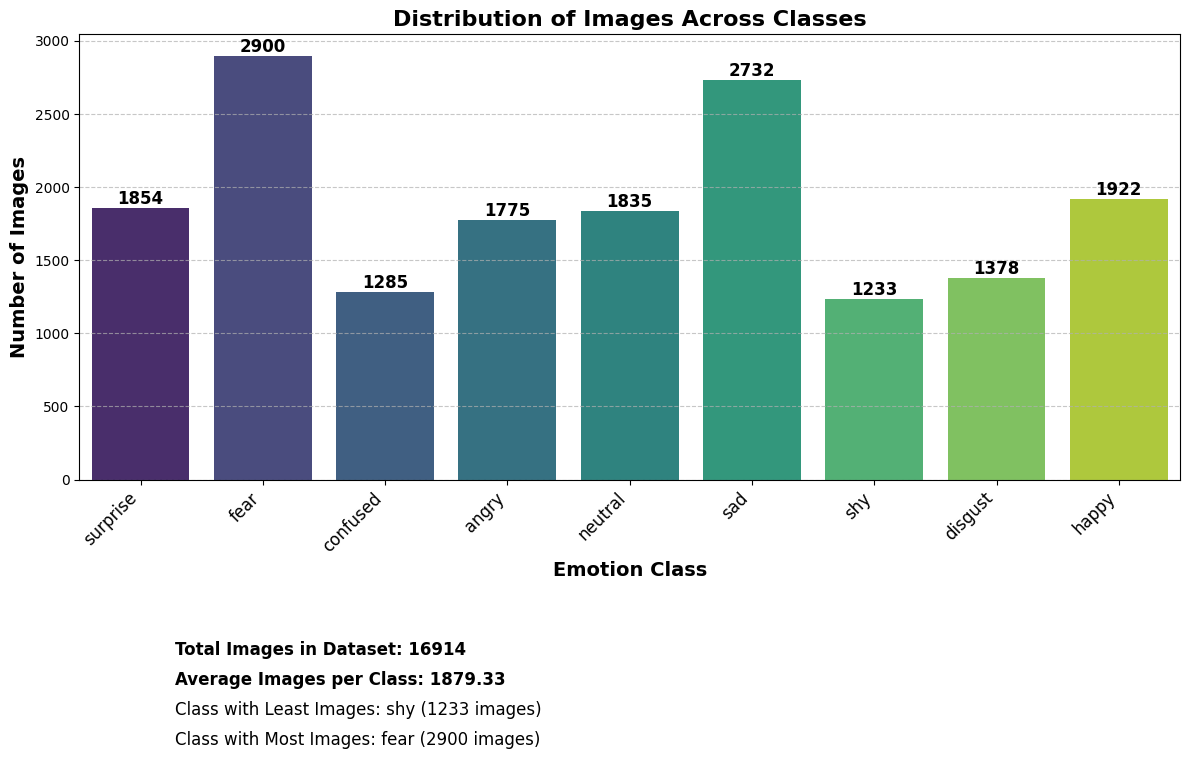

Unique Image Sizes: [[ 17  13]
 [ 30  25]
 [ 36  27]
 [ 37  31]
 [ 46  41]
 [ 53  42]
 [ 58  46]
 [ 64  46]
 [ 72  61]
 [ 73  58]
 [ 75  54]
 [ 78  65]
 [ 81  62]
 [ 82  59]
 [ 86  65]
 [ 93  68]
 [ 98  83]
 [ 99  78]
 [102  74]
 [109  86]
 [112 103]
 [120  95]
 [128 104]
 [129  95]
 [133  99]
 [136 108]
 [139 107]
 [146 110]
 [156 119]
 [157 119]
 [167 122]
 [170 117]
 [191 157]
 [200 153]
 [215 174]
 [226 189]
 [228 179]
 [232 160]
 [232 182]
 [253 202]
 [282 192]
 [293 231]
 [315 237]
 [418 248]
 [418 315]]
Training: 12177, Validation: 1354, Test: 3383


In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Set dataset path
DATASET_PATH = "/kaggle/input/dataset/fane_data"  # Update this if needed

# List class folders
class_folders = os.listdir(DATASET_PATH)
print("Classes Found:", class_folders)

# Select a few images from different categories
num_samples = 9
sample_images = []

for class_name in class_folders:
    class_path = os.path.join(DATASET_PATH, class_name)
    if os.path.isdir(class_path):  # Ensure it's a folder
        images = os.listdir(class_path)[:1]  # Take one image per class
        sample_images.extend([(class_name, os.path.join(class_path, img)) for img in images])

# Display sample images
plt.figure(figsize=(10, 10))
for i, (label, img_path) in enumerate(sample_images[:num_samples]):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB format

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.show()

# Create a DataFrame to plot the class distribution
class_counts = {class_name: len(os.listdir(os.path.join(DATASET_PATH, class_name))) for class_name in class_folders}
df_counts = pd.DataFrame(list(class_counts.items()), columns=["Class", "Count"])

# Plot class distribution
plt.figure(figsize=(12, 6))
ax = sns.barplot(x="Class", y="Count", data=df_counts, palette="viridis")

# Add labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Title and labels for axes
plt.title("Distribution of Images Across Classes", fontsize=16, fontweight='bold')
plt.xlabel("Emotion Class", fontsize=14, fontweight='bold')
plt.ylabel("Number of Images", fontsize=14, fontweight='bold')

# Show gridlines and rotate x-ticks
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right', fontsize=12)

# Show additional stats below the graph
total_images = df_counts["Count"].sum()
avg_class = df_counts["Count"].mean()
max_class = df_counts.loc[df_counts['Count'].idxmax()]
min_class = df_counts.loc[df_counts['Count'].idxmin()]

# Descriptive text
plt.figtext(0.15, -0.1, f"Total Images in Dataset: {total_images}", ha="left", fontsize=12, fontweight='bold')
plt.figtext(0.15, -0.15, f"Average Images per Class: {avg_class:.2f}", ha="left", fontsize=12, fontweight='bold')
plt.figtext(0.15, -0.25, f"Class with Most Images: {max_class['Class']} ({max_class['Count']} images)", ha="left", fontsize=12)
plt.figtext(0.15, -0.20, f"Class with Least Images: {min_class['Class']} ({min_class['Count']} images)", ha="left", fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

# Check image sizes
image_sizes = []
for class_name in class_folders:
    class_path = os.path.join(DATASET_PATH, class_name)
    if os.path.isdir(class_path):
        image_files = os.listdir(class_path)[:5]  # Check a few images per class
        for img_name in image_files:
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                image_sizes.append(img.shape[:2])  # (Height, Width)

# Convert to numpy array for analysis
image_sizes = np.array(image_sizes)
print("Unique Image Sizes:", np.unique(image_sizes, axis=0))

# Prepare images and labels for model training
images = []
labels = []

for class_name in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
            if img is not None:
                images.append(img)
                labels.append(class_name)

# Convert images and labels to numpy arrays
images = np.array(images, dtype=object)
labels = np.array(labels)

# Normalize images (convert pixel values to [0,1])
images = [img.astype('float32') / 255.0 for img in images]

# Encode labels
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

# Convert to one-hot encoding
labels_one_hot = to_categorical(labels_encoded)

# Split into train, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(images, labels_one_hot, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

print(f"Training: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

# Define EfficientNetB0 model
from tensorflow.keras import layers, models

input_layer = layers.Input(shape=(224, 224, 3))

base_model = EfficientNetB0(include_top=False, 
                            weights=None,  # No pre-trained weights from ImageNet since we are using custom weights
                            input_tensor=input_layer)

# Load custom weights from the provided path
base_model.load_weights('/kaggle/input/efficientnetb0/keras/efficientnetb0/1/efficientnetb0_notop.h5')

# Add custom layers on top of the EfficientNetB0 base
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)  # Global average pooling to reduce feature map size
x = layers.Dense(256, activation='relu')(x)  # Add a fully connected layer with ReLU activation
x = layers.Dropout(0.5)(x)  # Add dropout for regularization

# Output layer: Number of classes in your dataset (9 classes in this case)
predictions = layers.Dense(9, activation='softmax')(x)  # Softmax for multi-class classification



In [3]:
# Define the complete model
model = models.Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer='adam',  # Adam optimizer for better performance
              loss='sparse_categorical_crossentropy',  # Use categorical crossentropy for multi-class classification
              metrics=['accuracy'])  # Measure accuracy

# Define the data augmentation for training (e.g., random flips, rotations)
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values to [0, 1]
    rotation_range=30,  # Random rotations
    width_shift_range=0.2,  # Random horizontal shifts
    height_shift_range=0.2,  # Random vertical shifts
    shear_range=0.2,  # Random shear transformations
    zoom_range=0.2,  # Random zoom
    horizontal_flip=True,  # Random horizontal flips
    fill_mode='nearest'  # Fill missing pixels after transformations
)

# For validation, we typically only rescale the images (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)




In [4]:
# Create the generators
train_generator = train_datagen.flow_from_directory(
    '/kaggle/input/dataset/fane_data',  # Path to your training images folder
    target_size=(224, 224),  # Resize images to match the model input size
    batch_size=32,  # Set batch size
    class_mode='sparse',  # Use 'sparse' for integer labels
    shuffle=True  # Shuffle the data
)

val_generator = val_datagen.flow_from_directory(
    '/kaggle/input/dataset/fane_data',  # Path to your validation images folder
    target_size=(224, 224),  # Resize images to match the model input size
    batch_size=32,  # Set batch size
    class_mode='sparse',  # Use 'sparse' for integer labels
    shuffle=False  # Don't shuffle validation data
)

# Train the model
history = model.fit(
    train_generator,  # The training data generator
    epochs=10,  # Number of epochs
    validation_data=val_generator,  # The validation data generator
)

Found 16914 images belonging to 9 classes.
Found 16914 images belonging to 9 classes.
Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


529/529 ━━━━━━━━━━━━━━━━━━━━ 335s 503ms/step - accuracy: 0.3097 - loss: 1.8811 - val_accuracy: 0.1560 - val_loss: 2.2824
Epoch 2/10
529/529 ━━━━━━━━━━━━━━━━━━━━ 218s 408ms/step - accuracy: 0.4490 - loss: 1.5150 - val_accuracy: 0.4747 - val_loss: 1.4617
Epoch 3/10
529/529 ━━━━━━━━━━━━━━━━━━━━ 214s 400ms/step - accuracy: 0.5007 - loss: 1.3940 - val_accuracy: 0.4765 - val_loss: 1.4648
Epoch 4/10
529/529 ━━━━━━━━━━━━━━━━━━━━ 215s 402ms/step - accuracy: 0.5268 - loss: 1.3244 - val_accuracy: 0.5193 - val_loss: 1.3525
Epoch 5/10
529/529 ━━━━━━━━━━━━━━━━━━━━ 218s 408ms/step - accuracy: 0.5480 - loss: 1.2523 - val_accuracy: 0.5829 - val_loss: 1.1451
Epoch 6/10
529/529 ━━━━━━━━━━━━━━━━━━━━ 217s 405ms/step - accuracy: 0.5650 - loss: 1.2044 - val_accuracy: 0.5405 - val_loss: 1.3133
Epoch 7/10
529/529 ━━━━━━━━━━━━━━━━━━━━ 215s 401ms/step - accuracy: 0.5850 - loss: 1.1460 - val_accuracy: 0.5861 - val_loss: 1.1423
Epoch 8/10
529/529 ━━━━━━━━━━━━━━━━━━━━ 211s 395ms/step - accuracy: 0.6024 - loss: 1.10

**Saving the tained model**

In [5]:
# Save the trained model
model.save('/kaggle/working/facial_expression_model.h5')
print("Model saved successfully!")


Model saved successfully!


**Making Predictions**

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Predicted Expression: sad
Suggested Emoji: 😢


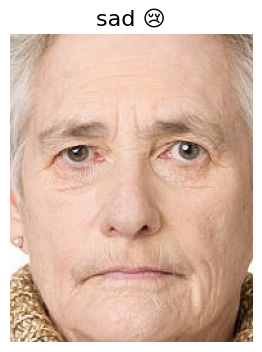

In [6]:
from tensorflow.keras.models import load_model
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the trained model
loaded_model = load_model('/kaggle/input/facial-expression-model/keras/default/1/facial_expression_model.h5')

# Define emoji mapping
emoji_map = {
    'surprise': '😲',
    'fear': '😨',
    'confused': '😕',
    'angry': '😠',
    'neutral': '😐',
    'sad': '😢',
    'shy': '😊',
    'disgust': '🤢',
    'happy': '😄'
}

# Image path for testing
img_path = '/kaggle/input/dataset/fane_data/sad/sad1006.jpg'  # Replace with your image

# Preprocess image
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (224, 224))
img_input = img_resized.astype('float32') / 255.0
img_input = np.expand_dims(img_input, axis=0)

# Predict
predictions = loaded_model.predict(img_input)
predicted_class_index = np.argmax(predictions)

# Decode label
predicted_class = label_encoder.inverse_transform([predicted_class_index])[0]
emoji = emoji_map.get(predicted_class, '❓')

# Print prediction
print(f"Predicted Expression: {predicted_class}")
print(f"Suggested Emoji: {emoji}")

# Display image with prediction and emoji
plt.figure(figsize=(4, 4))
plt.imshow(img_rgb)
plt.title(f"{predicted_class} {emoji}", fontsize=16)
plt.axis('off')
plt.show()
